# LinUCB Simulation on Synthetic SPF Scam Dataset

This notebook reuses the synthetic scam dataset generated in `synthetic-data.ipynb` to build a contextual bandit environment. Following the Week 10 LinUCB sample, we (1) load the data, (2) engineer numerical context features, (3) estimate per-contact-method reward parameters, and (4) run the disjoint LinUCB algorithm to see how quickly it learns which outreach channels (arms) lead to larger monetary impact.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(4014)


In [32]:
DATA_PATH = 'data/synthetic_spf_scam_cases_1H2025.csv'
df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df):,}")
df.head()


Rows: 19,665


,case_id,age_group,scam_type,contact_method,source_platform,requires_user_action,payment_method,urgency_level,loss_bucket,transaction_amount,is_scam
0,1,30-49,Job,Classified Ads,Classifieds,1,Card,Medium,2k-5k,3721.57,1
1,2,20-29,Phishing,Classified Ads,Classifieds,1,E-wallet,Medium,2k-5k,2168.36,1
2,3,20-29,Job,Phone Call,Phone,1,E-wallet,High,5k-10k,5811.74,1
3,4,30-49,Phishing,Social Media,Facebook,1,Card,Medium,<2k,187.44,1
4,5,<20,Job,Messaging,WhatsApp,1,E-wallet,Medium,10k-50k,12426.74,1


In [33]:
# Use categorical attributes that are known before picking an arm
base_features = [
    'age_group', 'scam_type', 'urgency_level',
    'payment_method', 'loss_bucket',
]
feature_df = pd.get_dummies(df[base_features], drop_first=False)
feature_df['requires_user_action'] = df['requires_user_action'].astype(float)
feature_df['log_amount_hint'] = np.log1p(df['transaction_amount'])
feature_matrix = feature_df.to_numpy(dtype=float)
feature_columns = feature_df.columns.tolist()

print(f"Feature matrix shape: {feature_matrix.shape}")
feature_df.head()


Feature matrix shape: (19665, 33)


,age_group_20-29,age_group_30-49,age_group_50-64,age_group_65+,age_group_<20,scam_type_E-commerce,scam_type_Fake Friend Call,scam_type_Government Impersonation,scam_type_Insurance Services,scam_type_Internet Love,...,payment_method_E-wallet,payment_method_PayNow/Transfer,loss_bucket_100k+,loss_bucket_10k-50k,loss_bucket_2k-5k,loss_bucket_50k-100k,loss_bucket_5k-10k,loss_bucket_<2k,requires_user_action,log_amount_hint
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,1.0,8.222170
1,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,1.0,7.682187
2,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,1.0,8.667807
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,1.0,5.238780
4,False,False,False,False,True,False,False,False,False,False,...,True,False,False,True,False,False,False,False,1.0,9.427686


In [34]:
# Define intervention arms
n_arms = 5
arm_names = [
    "Educational Nudge",
    "Active Verification",
    "Social Proof",
    "Delay",
    "Kill Switch"
]

n_features = feature_matrix.shape[1]

# Simulated true effectiveness of each intervention
np.random.seed(4014)
true_thetas = np.random.normal(0, 1, size=(n_arms, n_features))

# Optional: bias stronger interventions
true_thetas[3] += 1.5  # Delay
true_thetas[4] += 2.0  # Kill Switch

In [35]:
class LinUCB:
    def __init__(self, n_arms: int, n_features: int, alpha: float):
        self.n_arms = n_arms
        self.n_features = n_features
        self.alpha = alpha
        self.A = [np.identity(n_features) for _ in range(n_arms)]
        self.b = [np.zeros(n_features) for _ in range(n_arms)]

    def update(self, arm: int, context: np.ndarray, reward: float) -> None:
        self.A[arm] += np.outer(context, context)
        self.b[arm] += reward * context

    def recommend(self, context_matrix: np.ndarray):
        scores = np.zeros(self.n_arms)
        thetas = []

        for arm in range(self.n_arms):
            x = context_matrix[arm]

            theta = np.linalg.solve(self.A[arm], self.b[arm])

            A_inv_x = np.linalg.solve(self.A[arm], x)

            bonus = self.alpha * np.sqrt(x.T @ A_inv_x)
            p_arm = theta.T @ x + bonus

            scores[arm] = p_arm
            thetas.append(theta)

        return int(np.argmax(scores)), thetas, scores

In [36]:
# Helper: augment context
def augment_context(x, arm, n_arms):
    arm_one_hot = np.zeros(n_arms)
    arm_one_hot[arm] = 1
    return np.concatenate([x, arm_one_hot])

# Helper: simulate reward with noise
def simulate_one_time_reward(x, true_theta, noise_scale=250.0):
    signal = true_theta @ x
    noise = np.random.normal(scale=noise_scale)
    return signal + noise

# Context Sampler
class ContextSampler:
    def __init__(self, feature_matrix: np.ndarray):
        self.feature_matrix = feature_matrix
        self.n_samples = feature_matrix.shape[0]

    def sample(self) -> np.ndarray:
        idx = np.random.randint(0, self.n_samples)
        return self.feature_matrix[idx]


# Setup
sampler = ContextSampler(feature_matrix)

n_trials = 5000
alpha = 0.5

original_n_features = feature_matrix.shape[1]
augmented_n_features = original_n_features + n_arms

linucb = LinUCB(
    n_arms=n_arms,
    n_features=augmented_n_features,
    alpha=alpha
)

# Tracking variables
reward_history = np.zeros(n_trials)
regret_history = np.zeros(n_trials)
arm_history = np.zeros(n_trials, dtype=int)
theta_history = np.zeros((n_trials, n_arms, augmented_n_features))
score_history = np.zeros((n_trials, n_arms))


# Simulation loop
for t in range(n_trials):
    user_context = sampler.sample()

    context_matrix = np.array([
        augment_context(user_context, arm, n_arms)
        for arm in range(n_arms)
    ])

    arm_selected, thetas, scores = linucb.recommend(context_matrix)

    # observe reward
    observed_reward = simulate_one_time_reward(
        user_context,
        true_thetas[arm_selected]
    )

    # compute optimal (clean version)
    expected_rewards = true_thetas @ user_context
    optimal_reward = expected_rewards.max()

    linucb.update(
        arm_selected,
        context_matrix[arm_selected],
        observed_reward
    )

    reward_history[t] = observed_reward
    regret_history[t] = optimal_reward - observed_reward
    arm_history[t] = arm_selected
    theta_history[t] = thetas
    score_history[t] = scores


print(f"Completed {n_trials} LinUCB interactions over {n_arms} arms.")

Completed 5000 LinUCB interactions over 5 arms.


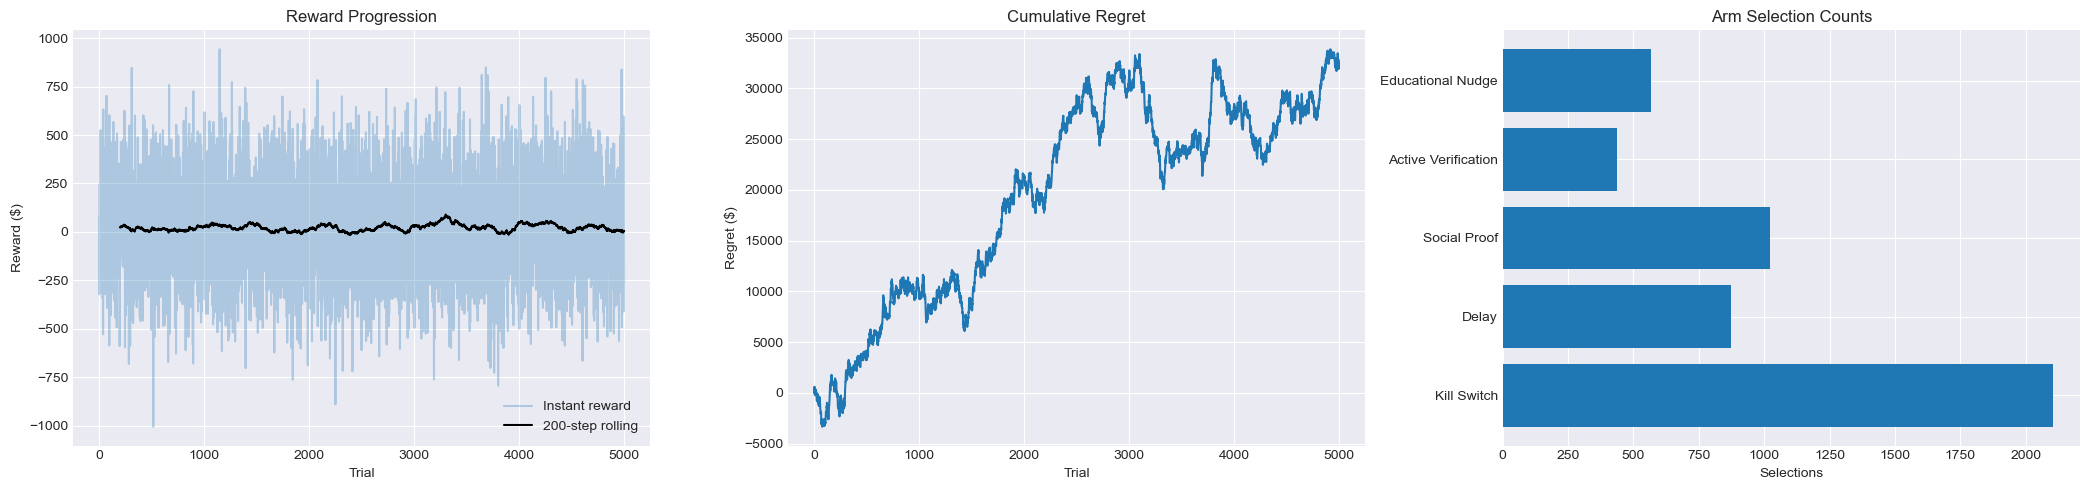

In [37]:
window = 200
rolling_reward = pd.Series(reward_history).rolling(window).mean()

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
axes[0].plot(reward_history, alpha=0.3, label='Instant reward')
axes[0].plot(rolling_reward, color='black', label=f'{window}-step rolling')
axes[0].set_title('Reward Progression')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Reward ($)')
axes[0].legend()

axes[1].plot(np.cumsum(regret_history))
axes[1].set_title('Cumulative Regret')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Regret ($)')

arm_counts = pd.Series(arm_history).map(dict(enumerate(arm_names))).value_counts().loc[arm_names]
axes[2].barh(arm_names, arm_counts)
axes[2].set_title('Arm Selection Counts')
axes[2].set_xlabel('Selections')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()
